# Dynamic Networks

Dynamic, or temporal, networks are a special subset of multilayer networks that allow you to examine changes in a network over time. NetworkX has no functionality for temporal networks, but it's straightforward to extend its multilayer functions.

What makes a network *dynamic* or *temporal* is typically an edge attribute. There are three types of temporal edge attributes:

- a specific timestamp for each edge, usually as a datetime object
- a beginning and ending time for each edge, usually as two separate attributes
- a time interval, usually an integer indicating an event-based time transition

It's often possible (and necessary) to convert attributes from one timeframe to another. Sometimes the time attributes will be present on a single layer graph, and sometimes every edge will have more than one time attribute. The latter situation is especially common for graphs with time intervals: the likelihood of an edge being in more than one time interval is high.

## Creating Multigraph Objects

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

A Multigraph is sometimes automatically created when your data has more than one of the same edge. Consider the Correlates of War dataset from the signed graph exercises:

In [2]:
MG = nx.read_pajek('../data/Cow_edit.net')
print(MG)

MultiGraph with 180 nodes and 41295 edges


Note that there are more than $180^2$ edges here, which would be the maximum possible in a standard static graph. In this graph, the Correlates of War dataset uses integers to label different time intervals.

You can also create both directed and undirected multigraphs with the `nx.Multigraph()` and `nx.MultiDiGraph()` objects. See [the NetworkX documentation](https://networkx.org/documentation/stable/reference/classes/multigraph.html#networkx.MultiGraph) for more details and example code.

## Understanding Keys

Multigraphs keeps track of the different layers of the graph using keys. A key is a special attribute that can only be accessed in a multigraph.

In [3]:
# Display the first 10 nodes of the multigraph, with keys
list(MG.edges(keys=True))[:10]

[('AFG', 'IRN', 0),
 ('AFG', 'IRN', 1),
 ('AFG', 'IRN', 2),
 ('AFG', 'IRN', 3),
 ('AFG', 'IRN', 4),
 ('AFG', 'IRN', 5),
 ('AFG', 'IRN', 6),
 ('AFG', 'IRN', 7),
 ('AFG', 'IRN', 8),
 ('AFG', 'IRN', 9)]

Once you have the individual keys, you could use the subgraph functions to isolate just one time interval of the graph:

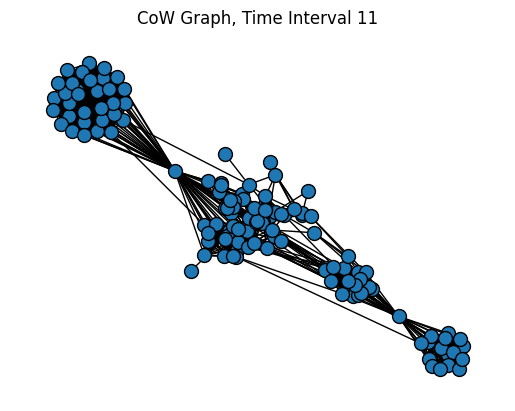

In [4]:
# Get edges from only interval 11 of the graph
edges11 = [(s, t, k) for s, t, k in MG.edges(keys=True) if k == 11]
SG = nx.edge_subgraph(MG, edges11)
plt.title("CoW Graph, Time Interval 11")
pos = nx.forceatlas2_layout(SG, distributed_action=True, max_iter=200)
nx.draw(SG, pos=pos, node_size=100, edgecolors="black")
plt.show()